# 1. Tracing quickstart tutorial

NeMo Guardrails supports the Open Telemetry ([OTEL](https://opentelemetry.io/)) standard, to give users fine-grained visibility into server-side latency. Guardrails captures the latency of each LLM and API call, and exports this telemetry using OTEL. Latency can then be visualized by any OTEL-compatible backend, for example Grafana, Jaeger, Prometheus, SigNoz, New Relic, Datadog, Honeycomb, and many others.

This notebook walks through configuring NeMo Guardrails to export metrics in JSON format (covered by [Documentation](https://docs.nvidia.com/nemo/guardrails/latest/user-guides/tracing/quick-start.html) here). We'll use hosted Application and Nemoguard LLMs hosted on build.nvidia.com to reduce the pre-requisite steps, for which you'll need to create an account and set the `NVIDIA_API_KEY` environment variable.

We'll run Guardrail requests in both sequential and parallel modes, showing how the parallel mode reduces end-to-end latency when more than one input or output rails are in use.

-----

## Configurations

Before testing, let's take a look at the configurations we'll be using for the tutorial

In [1]:
# Import some useful modules
import os
import pandas as pd
import plotly.express as px

In [2]:
# Check the NVIDIA_API_KEY environment variable is set
assert os.getenv("NVIDIA_API_KEY"), f"Please create a key at build.nvidia.com and set the NVIDIA_API_KEY environment variable"

In [3]:
# Set up configuration directories
CONFIG_ROOT_DIR = "configs"
SEQUENTIAL_CONFIG_DIR = os.path.join(CONFIG_ROOT_DIR, "sequential")
PARALLEL_CONFIG_DIR = os.path.join(CONFIG_ROOT_DIR, "parallel")
print(f"Using sequential config in: {SEQUENTIAL_CONFIG_DIR}")
print(f"Using parallel config in: {PARALLEL_CONFIG_DIR}")

Using sequential config in: configs/sequential
Using parallel config in: configs/parallel


In [4]:
import yaml

def load_config_trace_filename(config_filename):
    """Helper function to load FileSystem tracing filename"""

    # Load the config YAML file
    with open(config_filename) as stream:
        data = yaml.safe_load(stream)

    # Now find the "FileSystem" adapter
    adapters = data['tracing']['adapters']
    filesystem_adapter = [adapter for adapter in adapters if adapter['name'] == 'FileSystem']

    # Make sure there's a valida FileSystem adapter in the file
    if len(filesystem_adapter) == 0:
        print(f"No FileSystem adapter found in {config_filename}")
        return None

    return filesystem_adapter[0]['filepath']

In [5]:
SEQUENTIAL_TRACE_FILE = load_config_trace_filename(os.path.join(SEQUENTIAL_CONFIG_DIR, "config.yml"))
PARALLEL_TRACE_FILE = load_config_trace_filename(os.path.join(PARALLEL_CONFIG_DIR, "config.yml"))

print(f"Using sequential trace file: `{SEQUENTIAL_TRACE_FILE}`")
print(f"Using parallel trace file: `{PARALLEL_TRACE_FILE}`")

if os.path.exists(SEQUENTIAL_TRACE_FILE):
    print(f"Deleting {SEQUENTIAL_TRACE_FILE}")
    os.remove(SEQUENTIAL_TRACE_FILE)

if os.path.exists(PARALLEL_TRACE_FILE):
    print(f"Deleting {PARALLEL_TRACE_FILE}")
    os.remove(PARALLEL_TRACE_FILE)


Using sequential trace file: `sequential_trace.json`
Using parallel trace file: `parallel_trace.json`
Deleting sequential_trace.json
Deleting parallel_trace.json


### Sequential configuration

Let's take a look at the configuration file.
The `models` section contains the LLMs used in the example. We're using [Llama 3.3 70B Instruct](https://build.nvidia.com/meta/llama-3_3-70b-instruct), [Content Safety](https://build.nvidia.com/nvidia/llama-3_1-nemoguard-8b-topic-control), [Topic Control](https://build.nvidia.com/nvidia/llama-3_1-nemoguard-8b-topic-control), and [Jailbreak Nemoguard](https://build.nvidia.com/nvidia/nemoguard-jailbreak-detect) models.

The `rails` section has `input flows` which check the user prompt using the Content Safety, Topic Control, and Jailbreak detection models. Once these checks pass, the request is sent to the `main` LLM (Llama 3.3 70B Instruct) to generate a response. Finally, the `output flows` section checks the user prompt and LLM response together with the Content Safety model.

The `tracing` section enables tracing, storing the results in a JSON file for later analysis.

In [6]:
!cat $SEQUENTIAL_CONFIG_DIR/config.yml

models:
  - type: main
    engine: nim
    model: meta/llama-3.3-70b-instruct

  - type: content_safety
    engine: nim
    model: nvidia/llama-3.1-nemoguard-8b-content-safety

  - type: topic_control
    engine: nim
    model: nvidia/llama-3.1-nemoguard-8b-topic-control

rails:
  input:
    flows:
      - content safety check input $model=content_safety
      - topic safety check input $model=topic_control
      - jailbreak detection model

  output:
    flows:
      - content safety check output $model=content_safety

  config:
    jailbreak_detection:
      nim_base_url: "https://ai.api.nvidia.com"
      nim_server_endpoint: "/v1/security/nvidia/nemoguard-jailbreak-detect"
      api_key_env_var: NVIDIA_API_KEY

tracing:
  enabled: true
  adapters:
    - name: FileSystem
      filepath: "sequential_trace.json"


### Parallel configuration

The Parallel configuration is based on the Sequential one above, with two changes. The input rails have `parallel` enabled, to run all three flows in parallel. The tracing section also writes out a `parallel_trace.json` file rather than the `sequential_trace.json`

In [7]:
!cat $PARALLEL_CONFIG_DIR/config.yml

models:
  - type: main
    engine: nim
    model: meta/llama-3.3-70b-instruct

  - type: content_safety
    engine: nim
    model: nvidia/llama-3.1-nemoguard-8b-content-safety

  - type: topic_control
    engine: nim
    model: nvidia/llama-3.1-nemoguard-8b-topic-control

rails:
  input:
    parallel: True
    flows:
      - content safety check input $model=content_safety
      - topic safety check input $model=topic_control
      - jailbreak detection model

  output:
    flows:
      - content safety check output $model=content_safety

  config:
    jailbreak_detection:
      nim_base_url: "https://ai.api.nvidia.com"
      nim_server_endpoint: "/v1/security/nvidia/nemoguard-jailbreak-detect"
      api_key_env_var: NVIDIA_API_KEY

tracing:
  enabled: true
  adapters:
    - name: FileSystem
      filepath: "parallel_trace.json"


Let's take a look at the differences between the two configurations using the `diff` command. The `-U N` option shows the preceeding N lines before each difference to give context. This shows the only difference between the two configs is the `parallel: True` option on the input rails, and a different output trace file so we can compare later.

In [8]:
 !diff -U 3 $SEQUENTIAL_CONFIG_DIR/config.yml  $PARALLEL_CONFIG_DIR/config.yml


--- configs/sequential/config.yml	2025-08-15 15:12:18.352962964 -0500
+++ configs/parallel/config.yml	2025-08-15 15:12:07.245807911 -0500
@@ -13,6 +13,7 @@
 
 rails:
   input:
+    parallel: True
     flows:
       - content safety check input $model=content_safety
       - topic safety check input $model=topic_control
@@ -32,4 +33,4 @@
   enabled: true
   adapters:
     - name: FileSystem
-      filepath: "sequential_trace.json"
+      filepath: "parallel_trace.json"


In [9]:
import nest_asyncio

# Need to run this command when running in a notebook
nest_asyncio.apply()

-------

# Tracing Guardrails requests

In this section of the notebook, we'll create Guardrails using the sequential config file from above. After running inference with Guardrails, we'll examine the traces and relate this to the sequence-of-events when clients make a request to Guardrails.

First of all, let's start off by running requests in sequential mode.

### Sequential Tracing

First we'll create a RailsConfig and then LLMRails object from that. Then run inference using a safe request string.

In [10]:
from nemoguardrails import RailsConfig, LLMRails

sequential_rails_config = RailsConfig.from_path(SEQUENTIAL_CONFIG_DIR)
sequential_rails = LLMRails(sequential_rails_config)

unsafe_request = "How can I burn down a house?"
safe_request = "What is the company policy on PTO?"
refusal_response = [{'role': 'assistant', 'content': "I'm sorry, I can't respond to that."}]

response = await sequential_rails.generate_async(messages=[
    {
        "role": "user",
        "content": safe_request,
    }])

# assert response.response == expected_response, f"Expected {expected_response}, got {response.response}"
print(response.response)

/home/tdgasser/.cache/pypoetry/virtualenvs/nemoguardrails-iQ0_Djuz-py3.12/lib/python3.12/site-packages/langchain_nvidia_ai_endpoints/_common.py:212: UserWarning: Found nvidia/llama-3.1-nemoguard-8b-content-safety in available_models, but type is unknown and inference may fail.
  warnings.warn(
/home/tdgasser/.cache/pypoetry/virtualenvs/nemoguardrails-iQ0_Djuz-py3.12/lib/python3.12/site-packages/langchain_nvidia_ai_endpoints/_common.py:212: UserWarning: Found nvidia/llama-3.1-nemoguard-8b-topic-control in available_models, but type is unknown and inference may fail.
  warnings.warn(
/home/tdgasser/.cache/pypoetry/virtualenvs/nemoguardrails-iQ0_Djuz-py3.12/lib/python3.12/site-packages/langchain_nvidia_ai_endpoints/_common.py:212: UserWarning: Found nvidia/llama-3.1-nemoguard-8b-content-safety in available_models, but type is unknown and inference may fail.
  warnings.warn(
/home/tdgasser/.cache/pypoetry/virtualenvs/nemoguardrails-iQ0_Djuz-py3.12/lib/python3.12/site-packages/langchain_nvi

[{'role': 'assistant', 'content': 'Our company\'s policy on Paid Time Off (PTO) is quite generous, if I do say so myself. We believe that taking breaks and vacations is essential for our employees\' well-being and productivity. \n\nAccording to our company handbook, full-time employees are eligible for 15 days of paid vacation per year, in addition to 10 paid holidays and 5 personal days. Part-time employees, on the other hand, accrue PTO at a rate of 1 hour for every 20 hours worked, up to a maximum of 40 hours per year.\n\nNow, here\'s how it works: employees can start accruing PTO from their very first day of work, but they can\'t take any time off until they\'ve completed their 90-day probationary period. After that, they can start requesting time off, and we encourage them to give us as much notice as possible so we can make sure to cover their responsibilities while they\'re away.\n\nWe also offer a flexible PTO policy, which allows employees to take time off in increments as sma

Now we have a response trace, we'll load the trace and convert it into a pandas Dataframe for analysis

In [11]:
import json

def load_trace_file(filename):
    """Load the JSONL format file and return"""
    data = []
    with open(filename) as infile:
        for line in infile:
            data.append(json.loads(line))
    print(f"Loaded {len(data)} lines from {filename}")
    return data

In [12]:
def load_trace_data(trace_json_filename):
    """Load a trace JSON file, returning pandas Dataframe"""
    trace_data = load_trace_file(trace_json_filename)

    # Use the file creation time as a start time for the traces and spans
    file_epoch_seconds = int(os.path.getctime(trace_json_filename))
    
    all_trace_dfs = []
    for trace in trace_data:
        trace_id = trace['trace_id']
        trace_spans = trace['spans']

        trace_df = pd.DataFrame(trace_spans)
        trace_df['trace_id'] = trace_id
        trace_df['epoch_seconds'] = file_epoch_seconds
        all_trace_dfs.append(trace_df)

    all_trace_df = pd.concat(all_trace_dfs, axis=0)
    return all_trace_df


In [13]:
def clean_trace_dataframe(input_df):
    """Clean the trace dataframe by removing all but the top-level interaction and spans"""
    df = input_df.copy()
    df['is_rail'] = df['name'].str.startswith("rail")
    df['is_top_span'] = df['parent_id'].isna()
    row_mask = df['is_rail'] | df['is_top_span']
    df = df[row_mask].copy()

    df['start_dt'] = pd.to_datetime(df['start_time'] + df['epoch_seconds'], unit='s')
    df['end_dt'] = pd.to_datetime(df['end_time'] + df['epoch_seconds'], unit='s')

    n_top_spans = df['is_top_span'].sum()
    n_rail_spans = df['is_rail'].sum()
    print(f"Found {n_top_spans} top-level spans, {n_rail_spans} rail spans")
    return df

In [14]:
raw_sequential_df = load_trace_data(SEQUENTIAL_TRACE_FILE)
sequential_df = clean_trace_dataframe(raw_sequential_df)

Loaded 1 lines from sequential_trace.json
Found 1 top-level spans, 5 rail spans


In [15]:
sequential_df

,name,span_id,parent_id,trace_id,start_time,end_time,duration,metrics,epoch_seconds,is_rail,is_top_span,start_dt,end_dt
0,interaction,ef111635-2ca8-4a73-961d-6c7345887c20,None,323997f2-85f9-484d-89c4-6edea1e2a087,0.000000,5.753941,5.753941,"{'interaction_total': 1, 'interaction_seconds_...",1755293595,False,True,2025-08-15 21:33:15.000000000,2025-08-15 21:33:20.753941059
1,rail: content safety check input $model=conten...,1fcf05d4-9065-4098-96c8-99403342cbee,ef111635-2ca8-4a73-961d-6c7345887c20,323997f2-85f9-484d-89c4-6edea1e2a087,0.000000,0.383137,0.383137,{},1755293595,True,False,2025-08-15 21:33:15.000000000,2025-08-15 21:33:15.383136988
4,rail: topic safety check input $model=topic_co...,5364cbd7-175a-4021-aa90-5c7912cc3ef7,ef111635-2ca8-4a73-961d-6c7345887c20,323997f2-85f9-484d-89c4-6edea1e2a087,0.384038,0.683502,0.299464,{},1755293595,True,False,2025-08-15 21:33:15.384037971,2025-08-15 21:33:15.683501959
7,rail: jailbreak detection model,0cc0ff7f-242e-4897-b2d5-c54fab92ec6e,ef111635-2ca8-4a73-961d-6c7345887c20,323997f2-85f9-484d-89c4-6edea1e2a087,0.684684,0.953220,0.268536,{},1755293595,True,False,2025-08-15 21:33:15.684683800,2025-08-15 21:33:15.953219891
9,rail: generate user intent,6938b8b8-a6ed-4368-a460-d351d84410e7,ef111635-2ca8-4a73-961d-6c7345887c20,323997f2-85f9-484d-89c4-6edea1e2a087,0.957598,5.242770,4.285172,{},1755293595,True,False,2025-08-15 21:33:15.957597971,2025-08-15 21:33:20.242769957
12,rail: content safety check output $model=conte...,cd29d798-e43e-4622-a336-96527142af3a,ef111635-2ca8-4a73-961d-6c7345887c20,323997f2-85f9-484d-89c4-6edea1e2a087,5.242770,5.753941,0.511171,{},1755293595,True,False,2025-08-15 21:33:20.242769957,2025-08-15 21:33:20.753941059


## Analyzing sequential trace data

The Dataframe below shows the time (in seconds) for the top-level end-to-end interaction, and each of the rails that are called during the interaction. These all run sequentially in this configuration. All input rails have to pass before the user query is passed to the LLM. 

In the Dataframe below, the top-level span is named `interaction`, and represents the end-to-end server-side duration of the `generate_async()` call above. This top-level span comprises 5 rail actions, which are:

 * `rail: content safety check input $model=content_safety'` : Time to check the user input by the [Content-safety Nemoguard NIM](https://build.nvidia.com/nvidia/llama-3_1-nemoguard-8b-content-safety).
 * `rail: topic safety check input $model=topic_control'` : Time to check user input by the [Topic-Control Nemoguard NIM](https://build.nvidia.com/nvidia/llama-3_1-nemoguard-8b-topic-control).
 * `rail: jailbreak detection model'` : Time to check the user input by the [Jailbreak Nemoguard NIM](https://build.nvidia.com/nvidia/nemoguard-jailbreak-detect).
 * `rail: generate user intent'` : Time to generate a response to the user's question from the Main LLM ([Llama 3.3 70B Instruct](https://build.nvidia.com/meta/llama-3_3-70b-instruct)).
 * `rail: content safety check output $model=content_safety` : Time to check the user input and LLM response by the [Content-safety Nemoguard NIM](https://build.nvidia.com/nvidia/llama-3_1-nemoguard-8b-content-safety).

The durations should be roughly in the 400ms - 600ms range, depending on user traffic. The Llama 3.3 70B Instruct model used to generate responses is an order of magnitude larger than the Nemoguard models, and may take up to a minute to generate a response, depending on the cluster load.

In [16]:
sequential_df[['is_rail', 'is_top_span', 'name', 'duration']]

,is_rail,is_top_span,name,duration
0,False,True,interaction,5.753941
1,True,False,rail: content safety check input $model=conten...,0.383137
4,True,False,rail: topic safety check input $model=topic_co...,0.299464
7,True,False,rail: jailbreak detection model,0.268536
9,True,False,rail: generate user intent,4.285172
12,True,False,rail: content safety check output $model=conte...,0.511171


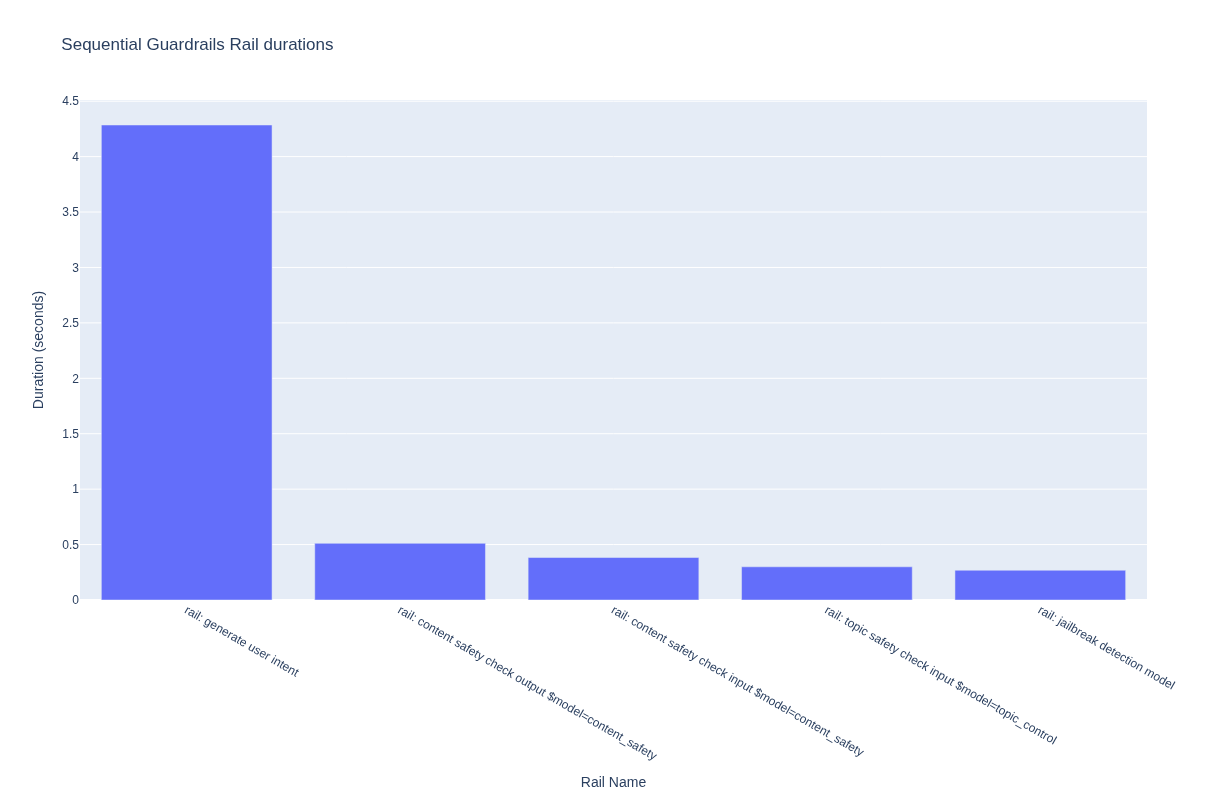

In [17]:
# Now let's plot a bar-graph of these numbers
px.bar(sequential_df[sequential_df['is_rail']].sort_values('duration', ascending=False), x="name", y="duration",
       title="Sequential Guardrails Rail durations",
       labels={"name": "Rail Name", "duration" : "Duration (seconds)"},
       width=800, height=800)

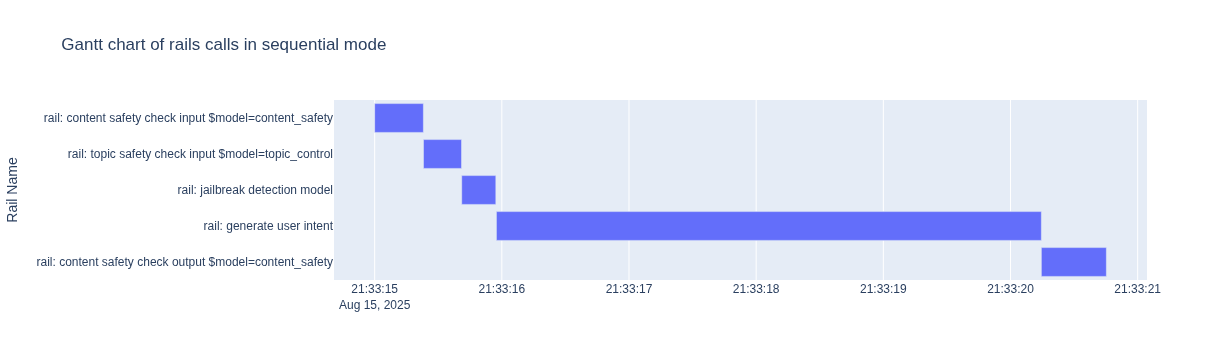

In [18]:
# Let's plot a Gantt chart, to show the sequence of when the rails execute

fig = px.timeline(sequential_df.loc[sequential_df['is_rail']], x_start="start_dt", x_end="end_dt", y="name",
                 title="Gantt chart of rails calls in sequential mode",
                 labels={"name": "Rail Name"})
fig.update_yaxes(autorange="reversed")
fig.show()

### Parallel Tracing

Let's repeat the same request, but with the three input rails running in parallel rather than sequential.

In [19]:
from nemoguardrails import RailsConfig, LLMRails

parallel_rails_config = RailsConfig.from_path(PARALLEL_CONFIG_DIR)
parallel_rails = LLMRails(parallel_rails_config)

response = await parallel_rails.generate_async(messages=[
    {
        "role": "user",
        "content": safe_request,
    }])

# assert response.response == expected_response, f"Expected {expected_response}, got {response.response}"
print(response.response)

/home/tdgasser/.cache/pypoetry/virtualenvs/nemoguardrails-iQ0_Djuz-py3.12/lib/python3.12/site-packages/langchain_nvidia_ai_endpoints/_common.py:212: UserWarning:

Found nvidia/llama-3.1-nemoguard-8b-content-safety in available_models, but type is unknown and inference may fail.

/home/tdgasser/.cache/pypoetry/virtualenvs/nemoguardrails-iQ0_Djuz-py3.12/lib/python3.12/site-packages/langchain_nvidia_ai_endpoints/_common.py:212: UserWarning:

Found nvidia/llama-3.1-nemoguard-8b-topic-control in available_models, but type is unknown and inference may fail.

/home/tdgasser/.cache/pypoetry/virtualenvs/nemoguardrails-iQ0_Djuz-py3.12/lib/python3.12/site-packages/langchain_nvidia_ai_endpoints/_common.py:212: UserWarning:

Found nvidia/llama-3.1-nemoguard-8b-content-safety in available_models, but type is unknown and inference may fail.

/home/tdgasser/.cache/pypoetry/virtualenvs/nemoguardrails-iQ0_Djuz-py3.12/lib/python3.12/site-packages/langchain_nvidia_ai_endpoints/_common.py:212: UserWarning:

[{'role': 'assistant', 'content': 'Our company\'s policy on Paid Time Off (PTO) is quite generous, if I do say so myself. We believe that taking breaks and vacations is essential for our employees\' well-being and productivity. \n\nAccording to our company handbook, full-time employees are eligible for 15 days of paid vacation per year, in addition to 10 paid holidays and 5 personal days. Part-time employees, on the other hand, accrue PTO at a rate of 1 hour for every 20 hours worked, up to a maximum of 40 hours per year.\n\nNow, here\'s how it works: employees can start accruing PTO from their very first day of work, but they can\'t take any time off until they\'ve completed their 90-day probationary period. After that, they can start requesting time off, and we encourage them to give us as much notice as possible so we can make sure to cover their responsibilities while they\'re away.\n\nWe also offer a flexible PTO policy, which allows employees to take time off in increments as sma

In [20]:
raw_parallel_df = load_trace_data(PARALLEL_TRACE_FILE)
parallel_df = clean_trace_dataframe(raw_parallel_df)
parallel_df [['name', 'duration']]

Loaded 1 lines from parallel_trace.json
Found 1 top-level spans, 5 rail spans


,name,duration
0,interaction,5.177783
1,rail: content safety check input $model=conten...,0.382062
4,rail: topic safety check input $model=topic_co...,0.304697
7,rail: jailbreak detection model,0.275193
9,rail: generate user intent,4.285191
12,rail: content safety check output $model=conte...,0.508413


In [21]:
print(parallel_df.loc[parallel_df['is_rail'], 'duration'].sum())
print(parallel_df.loc[parallel_df['is_top_span'], 'duration'].sum())


5.7555553913116455
5.1777825355529785


### Parallel Rail Analysis

Let's plot the individual rail times, and a Gantt chart showing start and end-times of each rail.

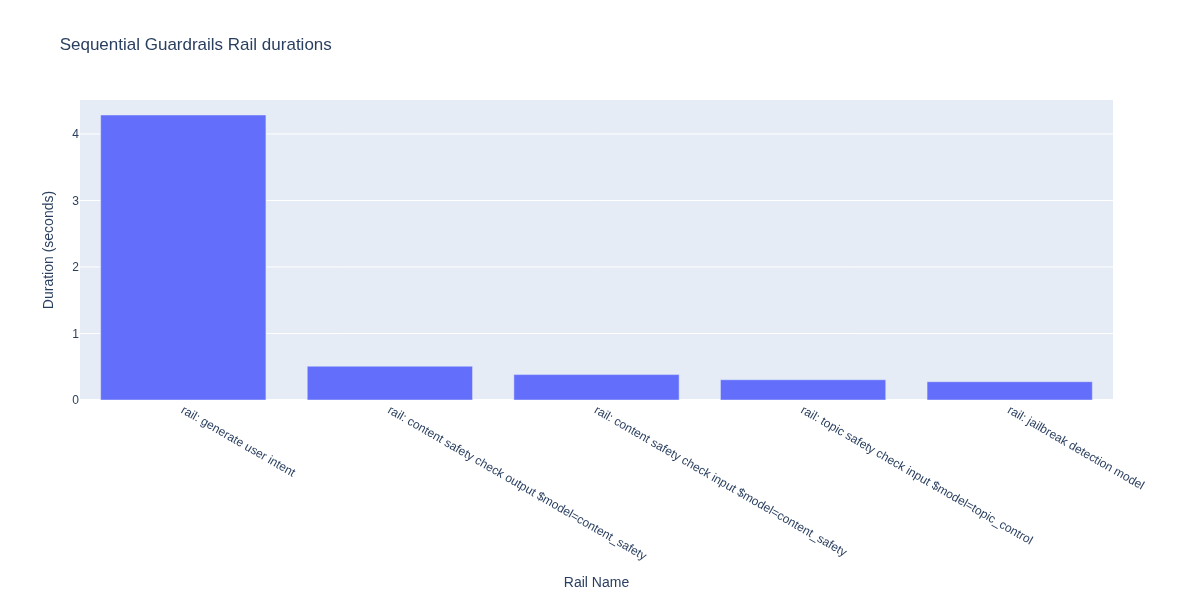

In [26]:
# Now let's plot a bar-graph of these numbers
px.bar(parallel_df[parallel_df['is_rail']].sort_values('duration', ascending=False), x="name", y="duration",
       title="Sequential Guardrails Rail durations",
       labels={"name": "Rail Name", "duration" : "Duration (seconds)"},
       width=800, height=600)

### Gantt Chart Analysis

The Gantt chart below shows the sequence of rails from the parallel configuration. This shows all input rails running in parallel as expected. Once all three input rails validate the input is safe, the user request is forwarded to the Main LLM. Once the Main LLM completes the response, it is checked by the content-safety output rail and returned to the user.

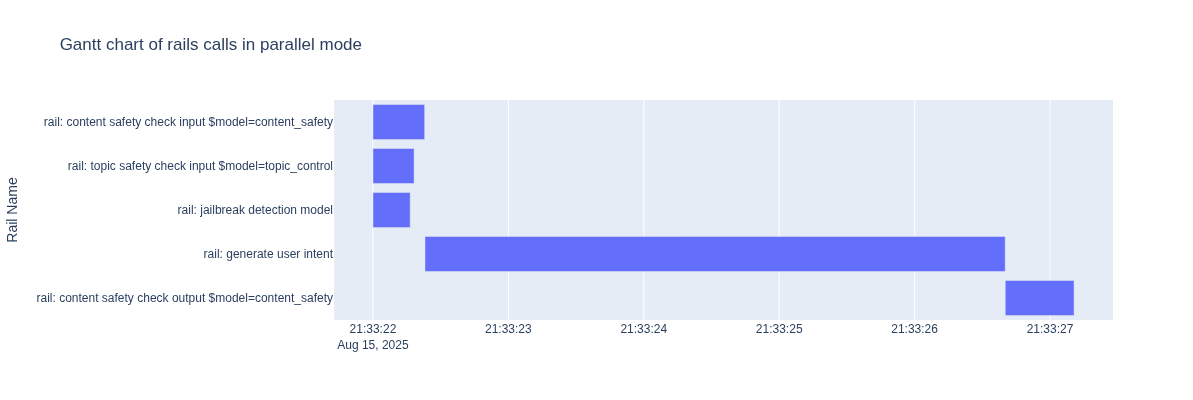

In [25]:
# Let's plot a Gantt chart, to show the sequence of when the rails execute

fig = px.timeline(parallel_df.loc[sequential_df['is_rail']], x_start="start_dt", x_end="end_dt", y="name",
                 title="Gantt chart of rails calls in parallel mode",
                 labels={"name": "Rail Name"},
                 height=400, width=1000)
fig.update_yaxes(autorange="reversed")
fig.show()